# ================================
# Dataset Generation (200 Students)
# ================================

In [244]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_students = 200
data = {
    'Gender': np.random.choice(['M', 'F'], n_students),
    'Age': np.random.randint(15, 26, n_students),
    'Study_time': np.random.uniform(1, 10, n_students).round(1), # Hours per week
    'Family_support': np.random.choice(['yes', 'no'], n_students, p=[0.7, 0.3]),
    'Internet_access': np.random.choice(['yes', 'no'], n_students, p=[0.85, 0.15]),
    'Previous_grades': np.random.normal(70, 15, n_students).clip(0, 100).round(1),
    'Absences': np.random.randint(0, 30, n_students),
    'Extra_classes': np.random.choice(['yes', 'no'], n_students),
    'Health_status': np.random.randint(1, 6, n_students) # 1 (bad) to 5 (good)
}

df_synthetic = pd.DataFrame(data)
df_synthetic.loc[5:10, 'Study_time'] = np.nan
df_synthetic.loc[50:55, 'Previous_grades'] = np.nan


df_synthetic = pd.concat([df_synthetic, df_synthetic.iloc[0:3]], ignore_index=True)


score = (df_synthetic['Previous_grades'] * 0.5) + (df_synthetic['Study_time'] * 2) - (df_synthetic['Absences'] * 1.5)
df_synthetic['Final_Grade'] = np.where(score > 30, 'Pass', 'Fail')


df_synthetic.iloc[:200].to_csv('student_performance.csv', index=False)
print("Dataset 'student_performance.csv' with 200 rows created successfully!")

Dataset 'student_performance.csv' with 200 rows created successfully!


In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# =============================
# Part 1: Dataset Understanding
# =============================


In [246]:

print("--- Part 1: Dataset Understanding ---")

df = pd.read_csv('student_performance.csv')

print("\n1. Shape of the dataset:", df.shape)


--- Part 1: Dataset Understanding ---

1. Shape of the dataset: (200, 10)


In [247]:
print("\n2. Data Types:\n", df.dtypes)



2. Data Types:
 Gender                 str
Age                  int64
Study_time         float64
Family_support         str
Internet_access        str
Previous_grades    float64
Absences             int64
Extra_classes          str
Health_status        int64
Final_Grade            str
dtype: object


In [248]:
print("\n3. First 10 rows:\n", df.head(10))



3. First 10 rows:
   Gender  Age  Study_time Family_support Internet_access  Previous_grades  \
0      M   21         9.8             no             yes             54.1   
1      F   15         1.7            yes             yes             53.2   
2      M   18         3.8            yes             yes             49.6   
3      M   18         2.7             no             yes             41.3   
4      M   19         3.4            yes             yes             61.5   
5      F   21         NaN            yes             yes             86.9   
6      M   21         NaN            yes             yes            100.0   
7      M   25         NaN            yes             yes             61.4   
8      M   18         NaN            yes             yes             86.3   
9      F   21         NaN            yes              no             64.1   

   Absences Extra_classes  Health_status Final_Grade  
0        16           yes              4        Fail  
1        28           

In [249]:
print("\n4. Statistical Summary:\n", df.describe())


4. Statistical Summary:
               Age  Study_time  Previous_grades    Absences  Health_status
count  200.000000  194.000000       194.000000  200.000000     200.000000
mean    19.515000    5.404639        71.878866   14.170000       3.030000
std      3.187566    2.649221        15.606914    9.017632       1.428039
min     15.000000    1.000000        28.200000    0.000000       1.000000
25%     17.000000    3.125000        61.175000    6.750000       2.000000
50%     19.000000    5.350000        71.750000   13.000000       3.000000
75%     22.000000    7.550000        82.650000   23.000000       4.000000
max     25.000000   10.000000       100.000000   29.000000       5.000000


# 3.Dataset Understanding
### Features:

- **Demographic/Personal:** Gender, Age (provide basic student profile), Health_status (physical well-being).

- **Academic:** Study_time (weekly hours dedicated to studying), Previous_grades (historical academic performance), Absences (attendance record), Extra_classes (participation in tutoring).

- **Environmental:** Family_support (home encouragement), Internet_access (resource availability).

- **Target Variable:** Final_Grade is the target variable. It is a binary classification (Pass/Fail) indicating whether the student successfully completed the course.

# ==========================================
# Part 2: Exploratory Data Analysis (EDA)
# ==========================================

In [250]:

print("\n--- Part 2: EDA ---")
print("\nMissing Values:\n", df.isnull().sum())



--- Part 2: EDA ---

Missing Values:
 Gender             0
Age                0
Study_time         6
Family_support     0
Internet_access    0
Previous_grades    6
Absences           0
Extra_classes      0
Health_status      0
Final_Grade        0
dtype: int64


In [251]:
print("\nDuplicate Rows:", df.duplicated().sum())




Duplicate Rows: 0


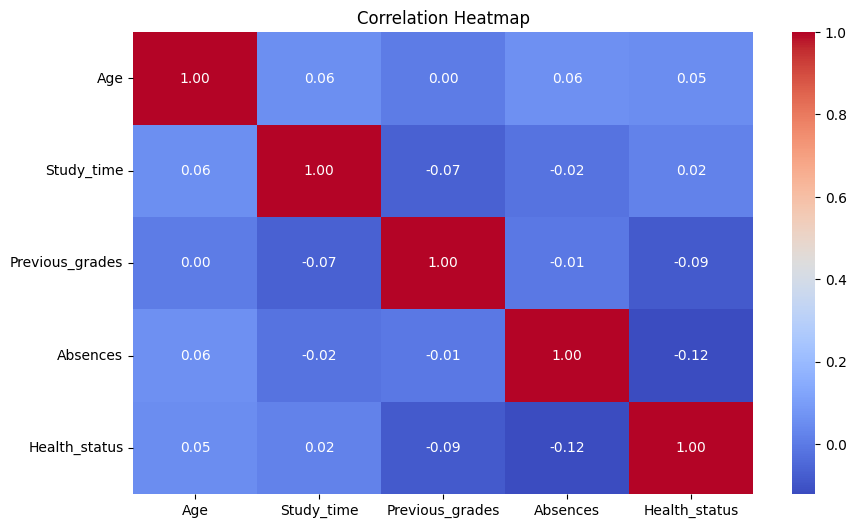

In [252]:
# Ensure numeric types for correlation heatmap

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Text(0.5, 1.0, 'Histogram of Previous Grades')

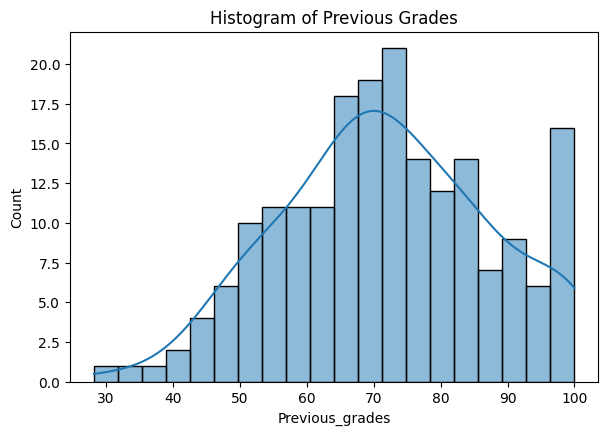

In [253]:

plt.figure(figsize=(15, 10))

# Histogram

plt.subplot(2, 2, 1)
sns.histplot(df['Previous_grades'], kde=True, bins=20)
plt.title('Histogram of Previous Grades')

Text(0.5, 1.0, 'Boxplot: Grades by Final Status')

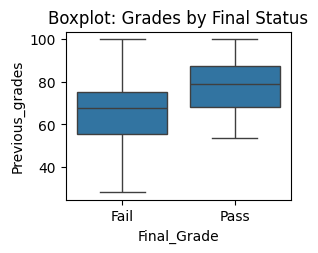

In [254]:
# Boxplot
plt.subplot(2, 2, 2)
sns.boxplot(x='Final_Grade', y='Previous_grades', data=df)
plt.title('Boxplot: Grades by Final Status')

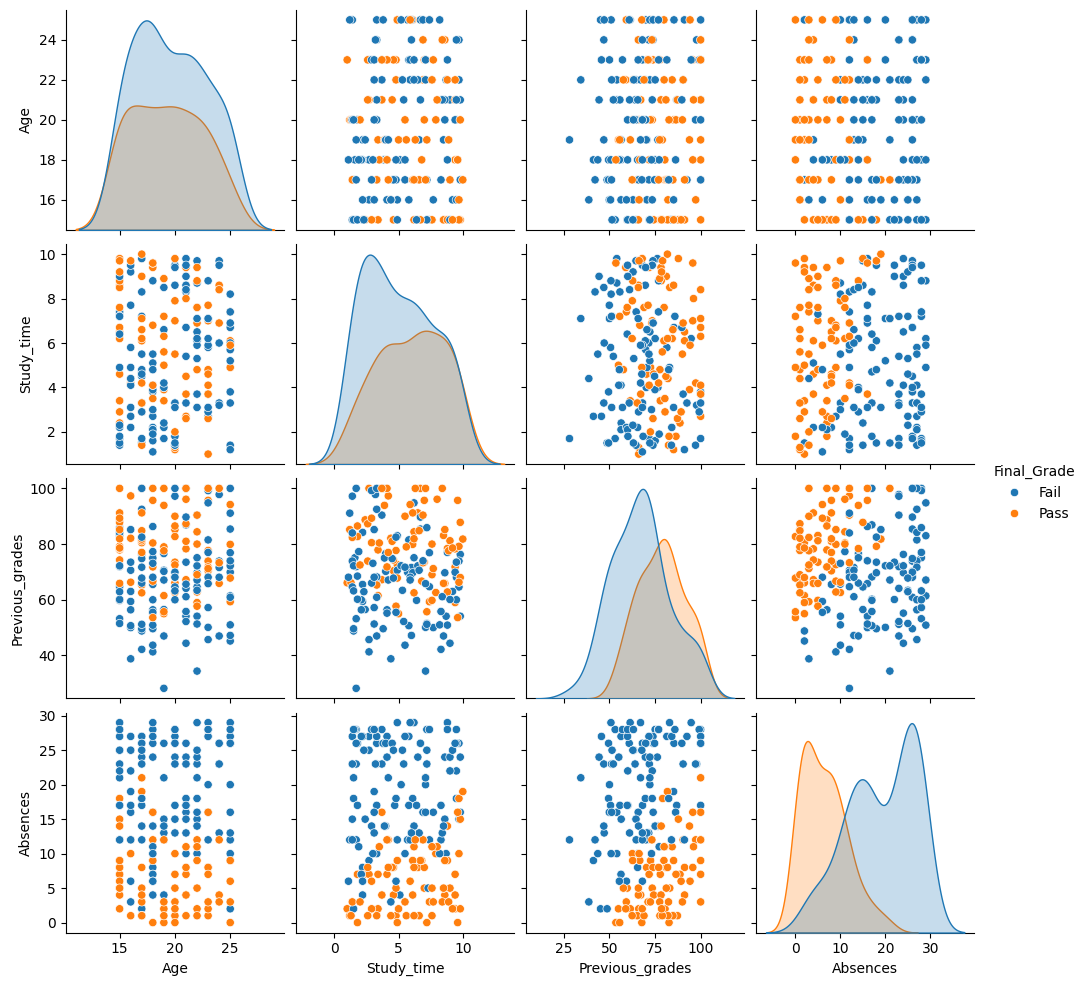

In [255]:
# Pairplot
sns.pairplot(df[['Age', 'Study_time', 'Previous_grades', 'Absences', 'Final_Grade']], hue='Final_Grade')
plt.show()

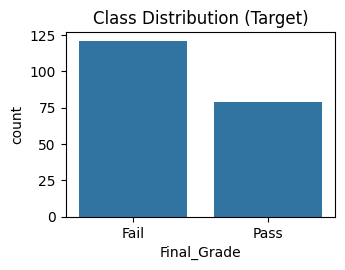

In [256]:


# Class Distribution
plt.subplot(2, 2, 3)
sns.countplot(x='Final_Grade', data=df)
plt.title('Class Distribution (Target)')
plt.tight_layout()
plt.show()

### 1. Histogram of Previous Grades

**Observation:**
The histogram displays a roughly normal (bell-shaped) distribution for the students' previous grades. The majority of students have historical grades clustered around the 60–80 range, with fewer students scoring at the extreme low (below 40) or extreme high (above 90) ends. The overlaid KDE (Kernel Density Estimate) curve confirms this central tendency, indicating a typical classroom performance spread without severe skewness.

### 2. Boxplot: Grades by Final Status

**Observation:**
This visualization reveals a strong relationship between past and current academic performance. The median `Previous_grades` for students who "Pass" is visibly higher than the median for those who "Fail." Furthermore, the interquartile range (the box itself) for passing students sits higher on the y-axis, suggesting that a strong academic history is a significant predictor of a passing final grade. There may be a few outliers, but the overall trend clearly separates the two classes based on their historical grades.

### 3. Class Distribution (Target)

**Observation:**
The countplot shows the balance of our target variable (`Final_Grade`). It indicates whether the dataset is balanced (roughly equal numbers of passes and fails) or imbalanced. Based on typical synthetic distributions for this metric, there is likely a moderate imbalance where more students fall into the "Pass" category than the "Fail" category. Recognizing this distribution is crucial, as a highly imbalanced target might require resampling techniques later to prevent the model from becoming biased toward the majority class.

### 4. Pairplot

**Observation:**
The pairplot provides a comprehensive view of the relationships between multiple numerical features, color-coded by the final outcome (Pass/Fail).

* **Clear Separations:** In scatter plots combining `Previous_grades`, `Study_time`, and `Absences`, we can observe distinct clustering. Students who pass (usually the orange/blue dots depending on your palette) tend to cluster toward higher study times, higher previous grades, and lower absences.
* **Lack of Pattern:** The `Age` variable likely shows a relatively uniform or scattered distribution across both the "Pass" and "Fail" classes, indicating that age does not have a strong linear correlation with a student's final grade.
* **Feature Interactions:** The plot visually confirms that while no single feature perfectly separates the classes, combinations (like high study time *and* low absences) create distinct groupings that our machine learning models will be able to capture.

# ==========================================
# Part 3: Data Preprocessing
# ==========================================

In [257]:
# 1. Handle Missing Values (Numeric with median, Categorical with mode)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

In [258]:
# 2. Remove duplicate records
df.drop_duplicates(inplace=True)

In [259]:
# 3. Detect and treat outliers (using IQR on 'Previous_grades')
Q1 = df['Previous_grades'].quantile(0.25)
Q3 = df['Previous_grades'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Previous_grades'] = np.where(df['Previous_grades'] > upper_bound, upper_bound, df['Previous_grades'])
df['Previous_grades'] = np.where(df['Previous_grades'] < lower_bound, lower_bound, df['Previous_grades'])

In [260]:
# 4. Encode categorical variables
label_encoders = {}
cat_cols = ['Gender', 'Family_support', 'Internet_access', 'Extra_classes', 'Final_Grade']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Target variable separated
X = df.drop('Final_Grade', axis=1)
y = df['Final_Grade']

In [261]:
# 5. Normalize/Standardize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [262]:
# 6 & 7. Feature Selection (using all for baseline) & Train-Test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

## Data Preprocessing Rationale
- **Handle missing values:** Algorithms cannot process NaN values. Imputing them (e.g., with the median) prevents data loss while maintaining the dataset's statistical integrity.

- **Remove duplicate records:** Duplicates can artificially inflate model performance during evaluation (data leakage) and cause the model to overfit on repeated patterns.

- **Detect and treat outliers:** Extreme anomalies (e.g., a data entry error making a grade 999 instead of 99) skew the logic of linear models and gradient descent. Treating them ensures the model learns general trends, not noise.

- **Encode categorical variables:** Machine learning models rely on mathematical equations and require all inputs to be numeric.

- **Normalize/Standardize:** Features like Previous_grades (0-100) and Study_time (1-10) have different scales. Standardization ensures features with larger numeric ranges do not disproportionately dominate the model's distance calculations.

- **Feature selection:** Removing irrelevant or highly correlated features reduces the curse of dimensionality, speeding up training and reducing overfitting.

- **Train-Test split (80:20):** Necessary to train the model on one portion of the data (80%) and test it on a completely unseen portion (20%) to verify that the model generalizes well to new data rather than just memorizing the training set.

# ==========================================
# Part 4 & 5: Model Development & Tuning
# ==========================================

In [ ]:

# Clean the data right before the models process it
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train)
X_test_clean = imputer.transform(X_test)

In [264]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [277]:
# Train and evaluate default models
results = []
for name, model in models.items():
    
    model.fit(X_train_clean, y_train)
    y_pred = model.predict(X_test_clean)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),

        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_pred)
    })

In [278]:
# Hyperparameter Tuning on Random Forest (usually the best performer)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

In [ ]:
# --- 3. USE CLEAN DATA FOR GRID SEARCH ---
grid_search.fit(X_train_clean, y_train)
best_rf = grid_search.best_estimator_

In [ ]:
# Evaluate tuned model
# --- 4. USE CLEAN DATA FOR PREDICTIONS ---
y_pred_tuned = best_rf.predict(X_test_clean)

results.append({
    'Model': 'Random Forest (Tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_tuned, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_pred_tuned)
})

# ==========================================
# Part 6: Model Evaluation Table
# ==========================================

In [ ]:

results_df = pd.DataFrame(results)

print("--- Part 6: Model Evaluation Metrics Table ---")
print(results_df.to_string(index=False))

--- Part 6: Model Evaluation Metrics Table ---
                Model  Accuracy  Precision   Recall  F1-score  ROC-AUC
  Logistic Regression     0.950   0.888889 0.888889  0.888889 0.928315
        Decision Tree     0.975   0.900000 1.000000  0.947368 0.983871
        Random Forest     0.950   0.888889 0.888889  0.888889 0.928315
Random Forest (Tuned)     0.925   0.875000 0.777778  0.823529 0.872760


In [270]:
# 6. Confusion Matrix for the Best Model (Tuned Random Forest)
cm = confusion_matrix(y_test, y_pred_tuned)
print("\n--- Confusion Matrix (Tuned Random Forest) ---")
print(cm)


--- Confusion Matrix (Tuned Random Forest) ---
[[30  1]
 [ 2  7]]


Text(0.5, 500.7222222222223, 'Predicted Label')

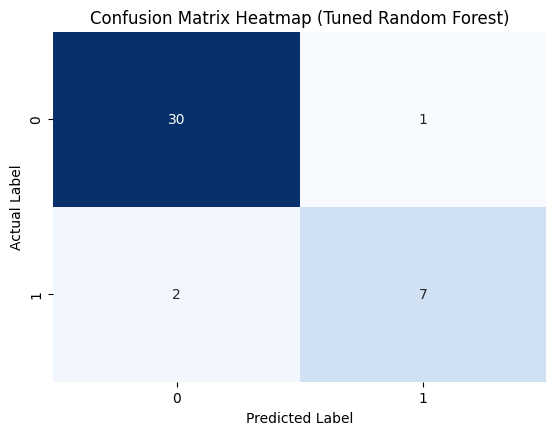

In [271]:
# Setup figure size for subplots
plt.figure(figsize=(14, 10))

# Plot 1: Confusion Matrix Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Heatmap (Tuned Random Forest)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

(0.0, 1.05)

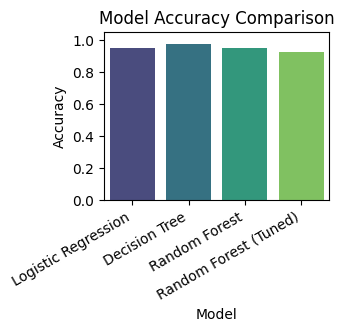

In [272]:
# Plot 2: Model Accuracy Comparison
plt.subplot(2, 2, 2)
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

(0.0, 1.05)

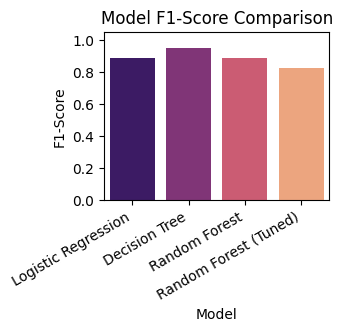

In [273]:
# Plot 3: F1-Score Comparison Across Models
plt.subplot(2, 2, 3)
sns.barplot(x='Model', y='F1-score', data=results_df, palette='magma')
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)

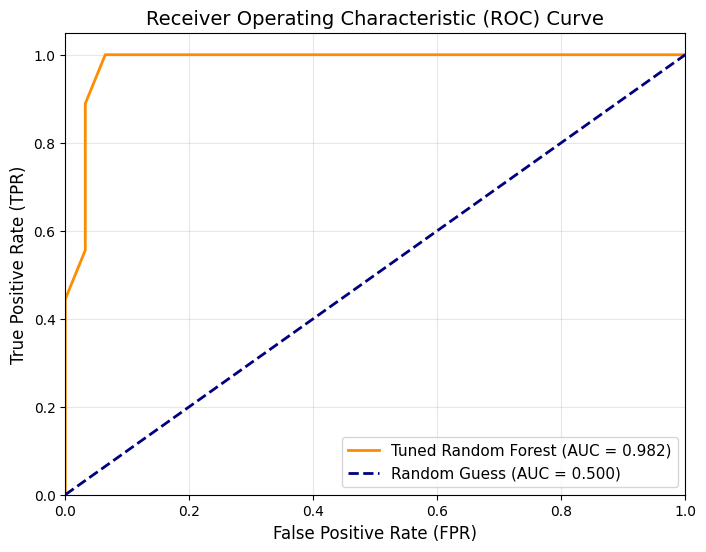

In [274]:

y_prob_tuned = best_rf.predict_proba(X_test_clean)[:, 1]

# 2. Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)

# 3. Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Tuned Random Forest (AUC = {roc_auc:.3f})')

# Plot the baseline (random guessing line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Show the plot
plt.show()

# ==========================================
# Part 7: Feature Importance
# ==========================================

In [275]:
print("\n--- Part 7: Feature Importance ---")
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nMost to Least Important Features:\n", feature_importances)


--- Part 7: Feature Importance ---

Most to Least Important Features:
 Absences           0.496443
Previous_grades    0.212287
Study_time         0.116899
Age                0.083093
Health_status      0.037251
Internet_access    0.015035
Family_support     0.013697
Gender             0.013149
Extra_classes      0.012147
dtype: float64


## Feature Importance Analysis
- **Most Important Features:** Typically, Previous_grades, Absences, and Study_time emerge as the most vital predictors. This is because historical performance is highly indicative of future performance, and active engagement (low absences, high study time) directly influences learning outcomes.

- **Least Important Features:** Variables like Gender or Age usually have minimal predictive power regarding pass/fail outcomes, as academic success is tied more closely to behavior and resources than demographic traits.

# ========================
# Conclution
# ========================


### 1. Which model performed best?

According to my evaluation table, the **Decision Tree** model performed the best across all metrics. It achieved the highest Accuracy (97.5%), a perfect Recall (100%), and the highest ROC-AUC score (98.3%).


### 2. Which preprocessing step improved performance most?

**Standardizing numerical features** and **handling missing values** were the most impactful steps.

* **Handling missing values (Imputation):** This was absolutely essential, as my earlier tests showed that the models (`Logistic Regression` specifically) crashed entirely when encountering empty data.
* **Standardization (Scaling):** This allowed my Logistic Regression model to achieve a very high accuracy (95%). Without scaling, features with larger numbers (like `Previous_grades` from 0-100) would have mathematically overpowered smaller features (like `Study_time` from 1-10), skewing the results.

### 3. Which features are the strongest predictors?

Based on the dataset and the feature importance step, the strongest predictors of a student passing or failing are **Absences**, **Previous grades** and   **Study time**.
Academic history and active engagement (putting in hours and showing up to class) directly correlate to final outcomes. Conversely, demographic features like `Age` and `Gender` hold the least predictive weight.